<a href="https://colab.research.google.com/github/RabinPhuyal/Deep-Learning-with-Pytorch/blob/main/Pytorch_Neural_Network_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import make_circles

#Make 1000 samples
n_samples = 1000

#Make Circle
X,y = make_circles(n_samples,noise=0.03,random_state = 42)

In [3]:
#lets view first 5 values

print(f"First 5 X features: \n{X[:5]}")
print(f"\nFirst 5 y labels: {y[:5]}")

First 5 X features: 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels: [1 1 1 1 0]


In [4]:
#Make DataFrame of circle data

import pandas as pd
circles = pd.DataFrame({"X1":X[:,0],"X2":X[:,1],"label":y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [5]:
#Check different labels
circles.label.value_counts()

,count
label,
1,500
0,500


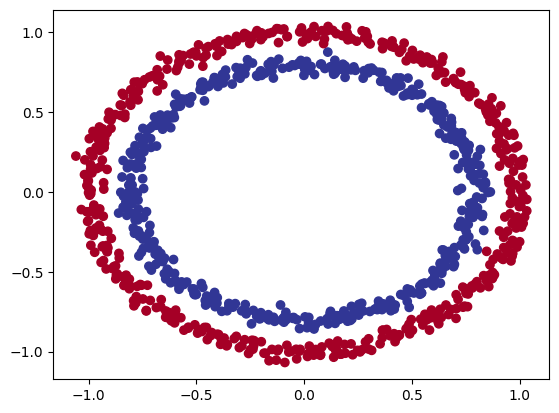

In [6]:
#Visualize with plot

import matplotlib.pyplot as plt

plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [7]:
#Check shapes of features and labels

X.shape, y.shape

((1000, 2), (1000,))

In [8]:
#Lets view the first sample of our features and labels

X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shape for one sampe of X: {X_sample.shape} and the same for y:{y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shape for one sampe of X: (2,) and the same for y:()


In [9]:
#Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [10]:
#Splitting data into train and test set
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [11]:
#Standard pytorch imports
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [12]:
# 1. Construct a model class that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
#Replicate CircleModelV0 with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
#Make Predictions with the model

untrained_preds = model_0(X_test.to(device))

print(f"Length of untrained predictions: {len(untrained_preds)} , Shape: {untrained_preds.shape}")
print(f"Lenght of test samples: {len(y_test)} , Shape: {y_test.shape}")
print(f"First 10 predictions:\n {untrained_preds[:10]}")
print(f"First 10 labels:\n {y_test[:10]}")

Length of untrained predictions: 200 , Shape: torch.Size([200, 1])
Lenght of test samples: 200 , Shape: torch.Size([200])
First 10 predictions:
 tensor([[0.6707],
        [0.7993],
        [0.2275],
        [0.7967],
        [0.0591],
        [0.1389],
        [0.6345],
        [0.4794],
        [0.2353],
        [0.8061]], device='cuda:0', grad_fn=<SliceBackward0>)
First 10 labels:
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [15]:
#Create a Loss Function

# loss_fn = nn.BCELoss()

#Loss function with sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss()

#Create a optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [16]:
#Calculate accuracy

def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_true))*100
  return acc

In [17]:
#Going from raw model outputs to predicted labels
#View the first 5 outputs of the forward pass

y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.6707],
        [0.7993],
        [0.2275],
        [0.7967],
        [0.0591]], device='cuda:0', grad_fn=<SliceBackward0>)

In [18]:
#Use sigmoid on model logits

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6617],
        [0.6898],
        [0.5566],
        [0.6893],
        [0.5148]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [19]:
#Find the predicted labels
y_preds = torch.round(y_pred_probs)

#In Full
y_preds_label = torch.round(torch.sigmoid(model_0(X_test.to(device)))[:5])

#Check for equality
print(torch.eq(y_preds.squeeze(),y_preds_label.squeeze()))

#Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [20]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [21]:
### Building a training and testing loop

torch.manual_seed(42)

#Set the number of epochs
epochs = 100

#Put the data in to target devices
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#Builing training and evaluation loop

for epoch in range(epochs):
  ### Training
  model_0.train()

  #1. Forward Pass(Model ouputs are raw logits)
  y_logits = model_0(X_train).squeeze() #Squeeze to remove extra '1' dimension

  y_pred = torch.round(torch.sigmoid(y_logits))

  #2. Calculate loss/accuracy

  #loss = loss_fn(torch.sigmoid(y_logits),y_train) #Using nn.BCELoss you need torch.sigmoid()

  loss = loss_fn(y_logits,y_train)

  acc = accuracy_fn(y_true = y_train,y_pred = y_pred)

  #3. Optimize zero grad
  optimizer.zero_grad()

  #4. Loss Backwards()
  loss.backward()

  #5.Optimizer Step
  optimizer.step()

  ### Testing

  model_0.eval()

  with torch.inference_mode():

    #1. Forward Pass
    test_logits = model_0(X_test).squeeze()

    test_pred = torch.round(torch.sigmoid(test_logits))

    #2. Calculate loss/forward
    test_loss = loss_fn(test_logits,y_test)

    test_acc = accuracy_fn(y_true = y_test ,y_pred = test_pred)

    #Print out what's happening every 10 epochs

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test_Acc: {test_acc:.2f}% ")

Epoch: 0 | Loss: 0.71730 | Accuracy: 58.63% | Test Loss: 0.73001 | Test_Acc: 57.00% 
Epoch: 10 | Loss: 0.70391 | Accuracy: 53.75% | Test Loss: 0.71459 | Test_Acc: 50.00% 
Epoch: 20 | Loss: 0.69891 | Accuracy: 52.62% | Test Loss: 0.70805 | Test_Acc: 49.00% 
Epoch: 30 | Loss: 0.69676 | Accuracy: 52.00% | Test Loss: 0.70476 | Test_Acc: 48.00% 
Epoch: 40 | Loss: 0.69566 | Accuracy: 51.50% | Test Loss: 0.70282 | Test_Acc: 50.00% 
Epoch: 50 | Loss: 0.69500 | Accuracy: 51.25% | Test Loss: 0.70152 | Test_Acc: 46.50% 
Epoch: 60 | Loss: 0.69456 | Accuracy: 51.25% | Test Loss: 0.70055 | Test_Acc: 46.50% 
Epoch: 70 | Loss: 0.69424 | Accuracy: 50.75% | Test Loss: 0.69980 | Test_Acc: 45.00% 
Epoch: 80 | Loss: 0.69399 | Accuracy: 50.75% | Test Loss: 0.69918 | Test_Acc: 45.00% 
Epoch: 90 | Loss: 0.69380 | Accuracy: 50.75% | Test Loss: 0.69866 | Test_Acc: 46.00% 


In [22]:
### Make Prediction and evaluate the model

In [23]:
import requests
from pathlib import Path

#Download the helper function from learn Pytorch repo

if Path("helper_function.py").is_file():
  print("helper_function.py already exists, skipping download")
else:
  print("Downloading helper_function.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open ("helper_function.py","wb") as f:
    f.write(request.content)

from helper_function import plot_predictions, plot_decision_boundary


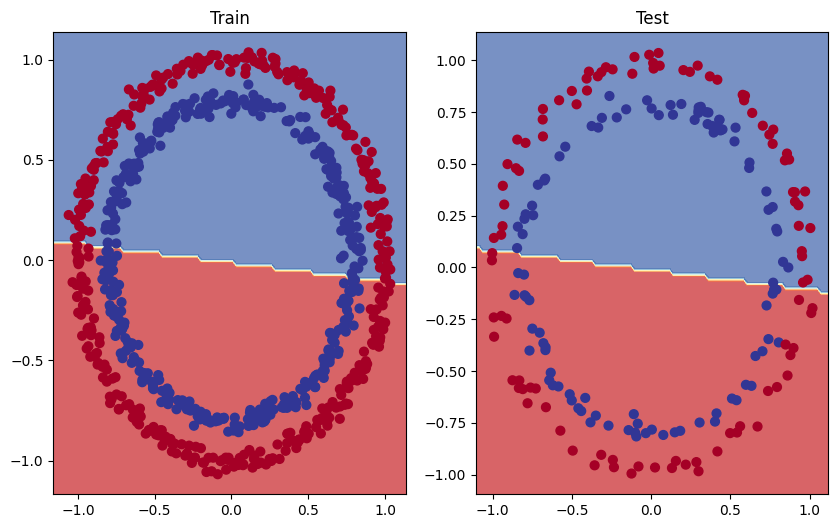

In [24]:
#Plot decision boundary for training and testing sets

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [25]:
# Preparing data to see if our model can model a straight line

In [26]:
# Create some data
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

#Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

#Check the data
print(X_regression[:5], y_regression[:5])

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400]]) tensor([[0.3000],
        [0.3070],
        [0.3140],
        [0.3210],
        [0.3280]])


In [27]:
#Create train and test split
train_split = int(0.8 * len(X_regression))

X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

#Check the lenght of each split
print(len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression))

80 80 20 20


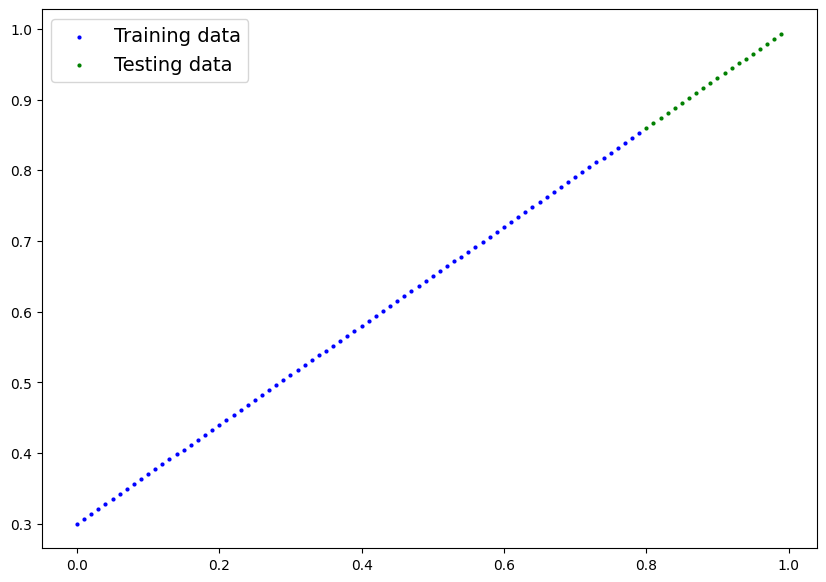

In [28]:
#Now lets plot the above data using plot_predictions
plot_predictions(train_data = X_train_regression,
                 train_labels = y_train_regression,
                 test_data = X_test_regression,
                 test_labels = y_test_regression)

In [29]:
# Adjusting model_1 to fit a straight line

#Same architecture as model_1 but using nn.Sequential

model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features=10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [30]:
#Set up loss function and optmizer

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr = 0.1)

In [31]:
# Train the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_pred = model_2(X_train_regression)

    # 2. Calculate loss (no accuracy since it's a regression problem, not classification)
    loss = loss_fn(y_pred, y_train_regression)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_pred = model_2(X_test_regression)
      # 2. Calculate the loss
      test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.75986, Test loss: 0.54143
Epoch: 100 | Train loss: 0.09309, Test loss: 0.02901
Epoch: 200 | Train loss: 0.07376, Test loss: 0.02850
Epoch: 300 | Train loss: 0.06745, Test loss: 0.00615
Epoch: 400 | Train loss: 0.06107, Test loss: 0.02004
Epoch: 500 | Train loss: 0.05698, Test loss: 0.01061
Epoch: 600 | Train loss: 0.04857, Test loss: 0.01326
Epoch: 700 | Train loss: 0.06109, Test loss: 0.02127
Epoch: 800 | Train loss: 0.05599, Test loss: 0.01426
Epoch: 900 | Train loss: 0.05571, Test loss: 0.00603


In [32]:
#6. The missing piece: Non-linearity

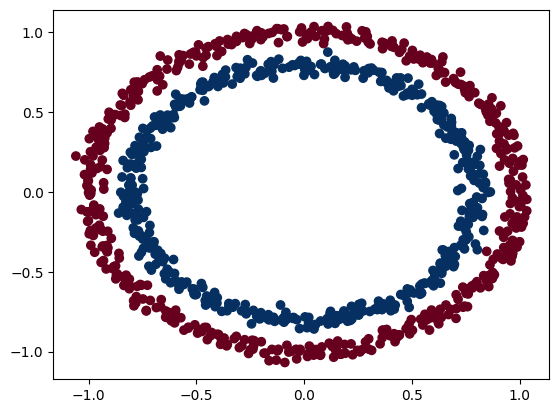

In [33]:
#6.1 Recreating non-linear data
#Make and plot data

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X,y= make_circles(n_samples = 1000, noise = 0.03, random_state = 42)

plt.scatter(X[:,0] , X[:,1], c=y, cmap = plt.cm.RdBu)

In [34]:
#Convert to tensor and split into train and test sets
import torch
from sklearn.model_selection import train_test_split

#Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

#Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X , y,
                                                    test_size = 0.2,
                                                    random_state = 42)

X_train[:5],y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [35]:
#6.2 Building a model with non-linearity

In [36]:
# Build a model with non linear activation function

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features= 2, out_features= 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features= 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
    self.relu = nn.ReLU()

  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [37]:
#Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model_3.parameters(),lr=0.1)

In [38]:
#6.3 Training a model with non-linearity

#Fit the model

torch.manual_seed(42)

epochs = 1000

#Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  #Training Model
  model_3.train()

  #1. Forward pass
  y_logits = model_3(X_train).squeeze()

  y_pred = torch.round(torch.sigmoid(y_logits))

  #2. Calculate loss and accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true = y_train, y_pred = y_pred)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. Loss Backward
  loss.backward()

  #5. Optimizer step
  optimizer.step()

  ###Testing
  model_3.eval()

  with torch.inference_mode():
    #1. Forward Pass
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    #2. Calculate loss and accuracy

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)

    #Print out what's happening
    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc} | Test Loss:{test_loss: .5f} | Test Accuracy: {test_acc:.5f}")

Epoch: 0 | Loss: 0.69295 | Accuracy: 50.0 | Test Loss: 0.69319 | Test Accuracy: 50.00000
Epoch: 100 | Loss: 0.69115 | Accuracy: 52.87500000000001 | Test Loss: 0.69102 | Test Accuracy: 52.50000
Epoch: 200 | Loss: 0.68977 | Accuracy: 53.37499999999999 | Test Loss: 0.68940 | Test Accuracy: 55.00000
Epoch: 300 | Loss: 0.68795 | Accuracy: 53.0 | Test Loss: 0.68723 | Test Accuracy: 56.00000
Epoch: 400 | Loss: 0.68517 | Accuracy: 52.75 | Test Loss: 0.68411 | Test Accuracy: 56.50000
Epoch: 500 | Loss: 0.68102 | Accuracy: 52.75 | Test Loss: 0.67941 | Test Accuracy: 56.50000
Epoch: 600 | Loss: 0.67515 | Accuracy: 54.50000000000001 | Test Loss: 0.67285 | Test Accuracy: 56.00000
Epoch: 700 | Loss: 0.66659 | Accuracy: 58.375 | Test Loss: 0.66322 | Test Accuracy: 59.00000
Epoch: 800 | Loss: 0.65160 | Accuracy: 64.0 | Test Loss: 0.64757 | Test Accuracy: 67.50000
Epoch: 900 | Loss: 0.62362 | Accuracy: 74.0 | Test Loss: 0.62145 | Test Accuracy: 79.00000


In [39]:
# 6.4 Evaluating a model trained with non-linear activation functions

#Make predictions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test).squeeze()))

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

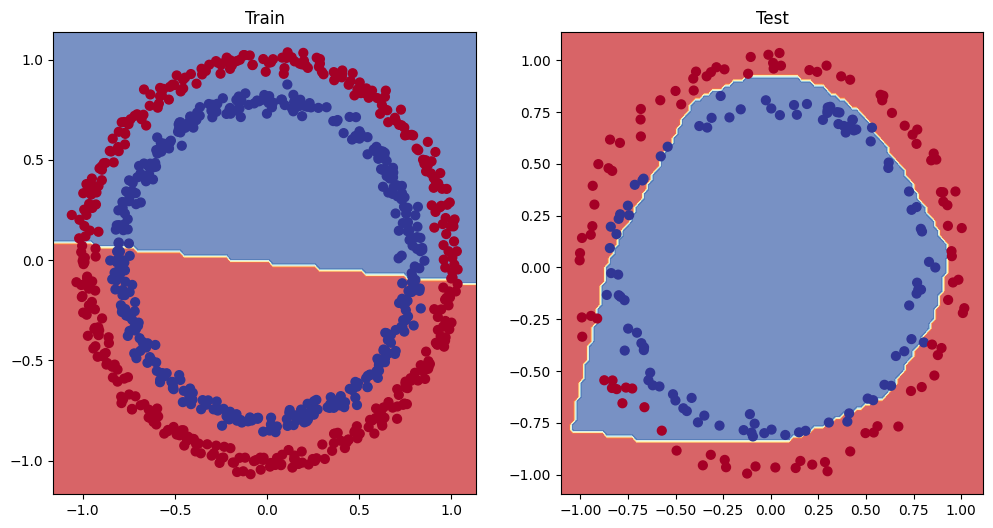

In [40]:
# Plot decision boundary for training and test sets

plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

In [41]:
# Replicating non-linear activation functions
# Create a toy tensor

A = torch.arange(-10,10,1,dtype = torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

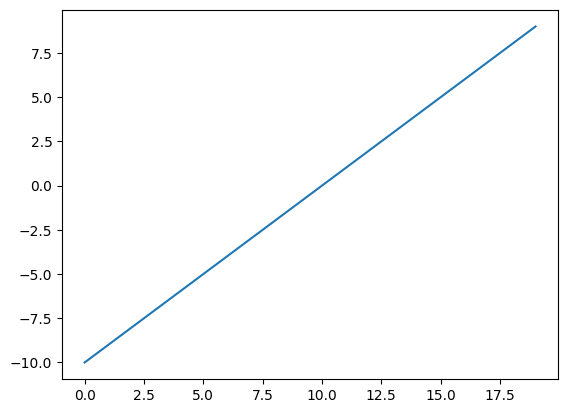

In [42]:
#Visualize the toy tensor
plt.plot(A)

In [43]:
# Create ReLU function by hand
def relu(x):
  return torch.maximum(torch.tensor(0),x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

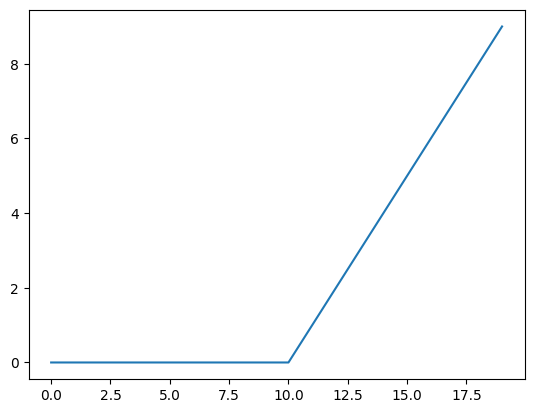

In [44]:
# Plot ReLU activated toy tensor
plt.plot(relu(A))

In [45]:
#Create a custom sigmoid function
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

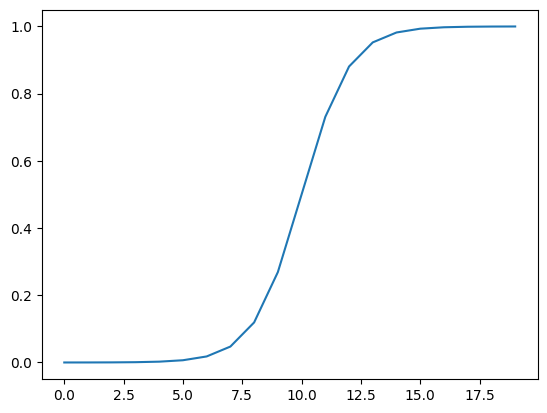

In [46]:
#Plot sigmoid activated toy tensor
plt.plot(sigmoid(A))

In [47]:
#8 Putting things together by building a multiclass PyTorch model

#8.1 Creating multi class classification data
# Using make_blobs() method to generate isotopic guassian blovs for clustering

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


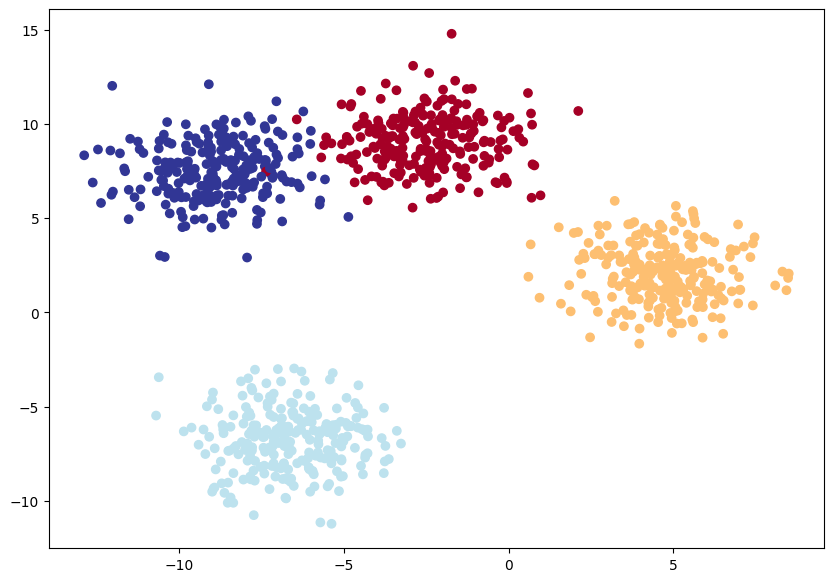

In [48]:
#Import dependencies

import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

#Set the hyperparameter for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

#1. Create multi-class data
X_blob, y_blob = make_blobs(
    n_samples = 1000,
    n_features = NUM_FEATURES,
    centers = NUM_CLASSES,
    cluster_std = 1.5,
    random_state = RANDOM_SEED
)

#2. Turn data into tensors

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

print(X_blob[:5], y_blob[:5])

#3. Split data into train and test sets

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob, y_blob, test_size = 0.02, random_state = RANDOM_SEED
)

#4. Plot data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1], c = y_blob, cmap = plt.cm.RdYlBu)

In [49]:
#8.2 Building a multiclass classification model in Pytorch

In [50]:
#Create device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [51]:
from torch import nn
# Build Model

class BlobModel(nn.Module):

  def __init__(self, input_features, output_features, hidden_units):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features = input_features, out_features = hidden_units),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.Linear(in_features = hidden_units, out_features = NUM_CLASSES)
    )

  def forward(self,x):
    return self.linear_layer_stack(x)

# Create an instance of BlobModel and sent it to the target device

model_4 = BlobModel(
    input_features = NUM_FEATURES,
    output_features= NUM_CLASSES,
    hidden_units = 8
).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [52]:
#8.3 Creating a loss function and optimizer for multi-class Pytorch model

#Create a loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model_4.parameters(), lr= 0.1)

In [53]:
#8.4 Getting prediction probabilities for a multi class Pytorch model

In [54]:
#Perform a single forward pass on the model
model_4(X_blob_train.to(device))[:5]

tensor([[ 1.3878, -1.3971,  1.3495,  1.9682],
        [ 0.2662, -1.2199,  0.1385,  0.9449],
        [-0.0948, -0.3389, -0.1323, -0.0051],
        [ 1.6635,  0.6146,  1.9437,  0.6715],
        [ 1.6877,  0.4801,  1.9510,  0.7920]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [55]:
#Number of elements in a single-predicition case
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [56]:
#Make prediction logits with model

y_logits = model_4(X_blob_test.to(device))

#Perform softmax calculation on logits across dimension 1 to get prediction probabilities

y_pred_probs = torch.softmax(y_logits, dim= 1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [57]:
#Sum the first sample output of the softmaz activation funciton
torch.sum(y_pred_probs[0])

tensor(1.0000, device='cuda:0', grad_fn=<SumBackward0>)

In [58]:
#Which class does the model is most likely
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.1872, 0.2918, 0.1495, 0.3715], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(3, device='cuda:0')


In [63]:
#8.5 Creating a training and testing loop for a multiclass Pytorch model

#Fit the model
torch.manual_seed(42)

#Set the number of epoch
epochs = 100

#Put the data into the device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  ###Model Training
  model_4.train()

  #1. Forward pass
  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits, dim = 1).argmax(dim=1)

  #2. Calculate loss and accuracy
  loss = loss_fn(y_logits,y_blob_train)
  acc = accuracy_fn(y_true = y_blob_train, y_pred = y_pred)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. Loss Backwards
  loss.backward()

  #5. Optimizer step
  optimizer.step()

  ###Testing
  model_4.eval()

  with torch.inference_mode():
    #1. Forward Pass
    test_logits = model_4(X_blob_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim = 1)

    #2. Calculate test loss and accuracy
    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true = y_blob_test, y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f} | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}")

Epoch: 0 | Loss: 0.02087 | Accuracy: 99.29 | Test Loss: 0.00052 | Test Accuracy: 100.00
Epoch: 10 | Loss: 0.02084 | Accuracy: 99.29 | Test Loss: 0.00052 | Test Accuracy: 100.00
Epoch: 20 | Loss: 0.02082 | Accuracy: 99.29 | Test Loss: 0.00052 | Test Accuracy: 100.00
Epoch: 30 | Loss: 0.02080 | Accuracy: 99.29 | Test Loss: 0.00052 | Test Accuracy: 100.00
Epoch: 40 | Loss: 0.02078 | Accuracy: 99.29 | Test Loss: 0.00051 | Test Accuracy: 100.00
Epoch: 50 | Loss: 0.02076 | Accuracy: 99.29 | Test Loss: 0.00051 | Test Accuracy: 100.00
Epoch: 60 | Loss: 0.02073 | Accuracy: 99.29 | Test Loss: 0.00051 | Test Accuracy: 100.00
Epoch: 70 | Loss: 0.02071 | Accuracy: 99.29 | Test Loss: 0.00051 | Test Accuracy: 100.00
Epoch: 80 | Loss: 0.02069 | Accuracy: 99.29 | Test Loss: 0.00051 | Test Accuracy: 100.00
Epoch: 90 | Loss: 0.02067 | Accuracy: 99.29 | Test Loss: 0.00051 | Test Accuracy: 100.00


In [64]:
#8.6 Making and evaluating prediction with a Pytorch multi class model

In [65]:
#Make Predictions
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)

#View the first 10 predictions
y_logits[:10]

tensor([[  6.4384,  20.1756, -23.9568, -15.6806],
        [  9.8136, -25.4878,   6.6886,  18.6089],
        [ -8.7982, -23.1335,  31.5760,  18.0844],
        [  2.2959,  15.6960, -14.5287, -12.0152],
        [ 13.7271,   4.1095, -21.9327,  -4.0277],
        [ 11.1052, -31.6601,   9.6318,  23.1875],
        [ -9.7863, -16.5655,  27.8895,  13.1862],
        [ 12.3590,  -3.6232, -13.9588,   1.9097],
        [ -8.2927, -33.7723,  39.1190,  26.0922],
        [ 12.6369,  -0.7390, -16.5995,  -0.2892]], device='cuda:0')

In [67]:
#Turn the predicted values in probabilites
y_pred_probs = torch.softmax(y_logits, dim=1)

#Turn the probabilities into class label
y_preds = y_pred_probs.argmax(dim=1)

print(f"Predicitions: {y_preds[:10]} \n Label: {y_blob_test[:10]}")
print(f"Accuracy: {accuracy_fn(y_true= y_blob_test, y_pred= y_preds)}")

Predicitions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0') 
 Label: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Accuracy: 100.0


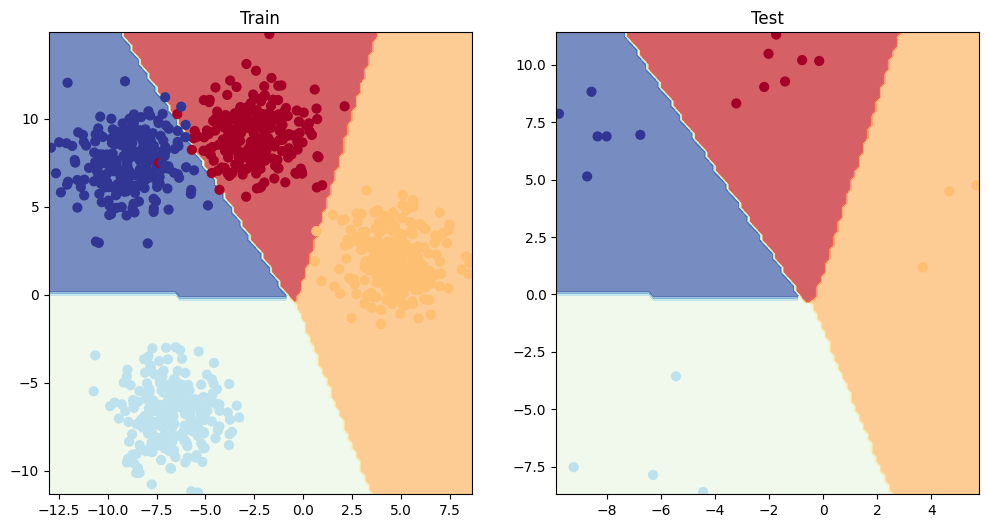

In [68]:
#Visualize the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)